In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("./out_csv")

LOG_calibracao = pd.read_csv(base / "LOG_calibracao2.csv")


In [14]:
import numpy as np
import pandas as pd

def convert_imu_counts(
    df: pd.DataFrame,
    acc_range_g: int,
    gyro_range_dps: int,
    g0: float = 9.80665,
) -> pd.DataFrame:
    """
    Converte IMU counts (MPU) para unidades físicas.
    
    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo colunas ax*, ay*, az*, gx*, gy*, gz*
    acc_range_g : int
        Faixa do acelerômetro (2, 4, 8 ou 16)
    gyro_range_dps : int
        Faixa do giroscópio (250, 500, 1000 ou 2000)
    g0 : float
        Aceleração da gravidade (m/s²)

    Retorna
    -------
    df_out : pandas.DataFrame
        Novo DataFrame com colunas convertidas (m/s² e deg/s)
    """

    acc_lsb_per_g = {
        2: 16384.0,
        4: 8192.0,
        8: 4096.0,
        16: 2048.0,
    }

    gyro_lsb_per_dps = {
        250: 131.0,
        500: 65.5,
        1000: 32.8,
        2000: 16.4,
    }

    if acc_range_g not in acc_lsb_per_g:
        raise ValueError(f"Faixa de accel inválida: {acc_range_g} g")

    if gyro_range_dps not in gyro_lsb_per_dps:
        raise ValueError(f"Faixa de gyro inválida: {gyro_range_dps} dps")

    acc_scale = g0 / acc_lsb_per_g[acc_range_g]
    gyro_scale = 1.0 / gyro_lsb_per_dps[gyro_range_dps]

    df_out = df.copy()

    # --- ACC ---
    for col in df.columns:
        if col.startswith(("ax", "ay", "az")):
            df_out[col + "_ms2"] = df[col] * acc_scale

    # --- GYRO ---
    for col in df.columns:
        if col.startswith(("gx", "gy", "gz")):
            df_out[col + "_dps"] = df[col] * gyro_scale

    return df_out

In [15]:
two_imus_n = convert_imu_counts(
    LOG_calibracao,
    acc_range_g=8,       # ±8 g
    gyro_range_dps=500   # ±500 dps
)

In [16]:
t = (two_imus_n["t_us"] - two_imus_n["t_us"][0])/1000000
t

0           0.000000
1           0.001000
2           0.002000
3           0.003000
4           0.004000
             ...    
158715    159.124226
158716    159.125226
158717    159.126226
158718    159.127226
158719    159.128226
Name: t_us, Length: 158720, dtype: float64

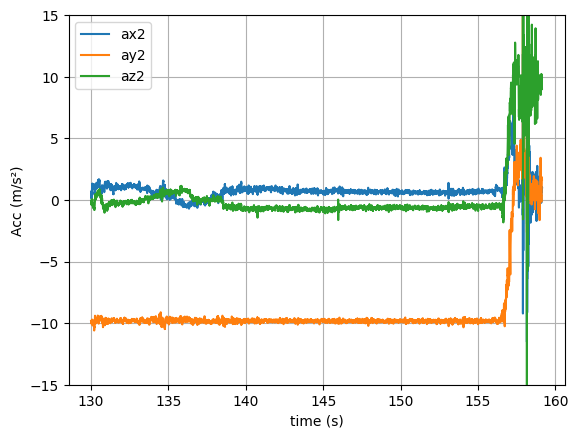

In [41]:
# Labels
get_all =0
limits = [130, 160]
new_two_imus = two_imus_n
t_plot = t

if not get_all:
    min_idx = (t - limits[0]).abs().idxmin()
    max_idx = (t - limits[1]).abs().idxmin()

    new_two_imus = new_two_imus.iloc[min_idx:max_idx]
    t_plot = t_plot[min_idx:max_idx]

plt.figure()

plt.plot(t_plot, new_two_imus["ax2_ms2"], label="ax2")
plt.plot(t_plot, new_two_imus["ay2_ms2"], label="ay2")
plt.plot(t_plot, new_two_imus["az2_ms2"], label="az2")

plt.ylim([-15, 15])
plt.xlabel("time (s)")
plt.ylabel("Acc (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

#plt.plot(t_plot, new_two_imus["ax1_ms2"])
#plt.plot(t_plot, new_two_imus["ay1_ms2"])
#plt.plot(t_plot, new_two_imus["az1_ms2"])

#plt.ylabel("Acc (m/s^2)")
#plt.xlabel("time (s)")

=== Face medians (IMU2) ===
      ax2_ms2   ay2_ms2    az2_ms2       norm
+z  -1.271321  0.237026   9.205705   9.296099
-z  -1.036689 -0.050278 -10.158598  10.211482
+x  -0.488417  9.804256  -0.237026   9.819275
-x  -0.974440 -0.077812 -10.132261  10.179308
+y  -9.387665 -0.885855  -0.169988   9.430900
-y  10.014946  0.624887  -0.337582  10.040099

=== Bias (m/s^2) ===
{'x': np.float64(-0.7314286071777343), 'y': np.float64(-0.1304839904785156), 'z': np.float64(-0.4764461303710936)}

=== Scale gain k (multiply) ===
{'x': np.float64(40.354679802955665), 'y': np.float64(-12.98256735340729), 'z': np.float64(1.0128585558852619)}

[AVISO] Ganho negativo em: ['y'] 
Isso indica eixo invertido ou alguma face +/− trocada. A calibração ainda pode ser usada, mas revise.

=== Validation per face (median of calibrated) ===
+z  vec={'ax2_cal': -21.787187931034488, 'ay2_cal': -4.771222741679873, 'az2_cal': 9.806649999999998}  norm=24.3642 (target 9.8066)
-z  vec={'ax2_cal': -12.318698275862072, 'ay2_c

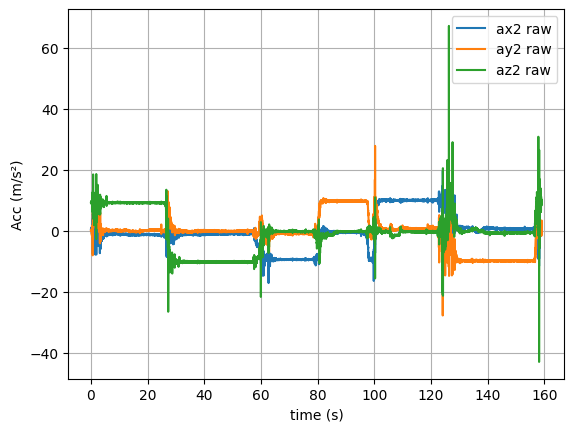

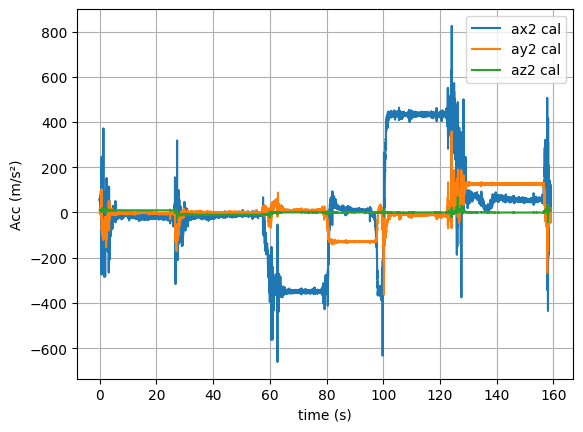

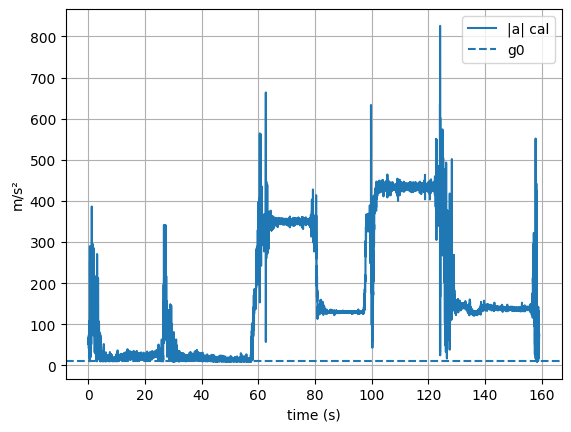

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g0 = 9.80665
cols = ["ax2_ms2", "ay2_ms2", "az2_ms2"]

faces_t = {
    "+z": ( 7,  25),
    "-z": ( 35,  55),
    "+x": ( 110,  120),
    "-x": ( 67,  77.5),
    "+y": ( 87.5,  95),
    "-y": ( 140, 155),
}

# --- helpers ---
t_arr = np.asarray(t_plot).ravel()

def t_to_idx(t, t0, t1):
    idx0 = (t - t0).abs().idxmin()
    idx1 = (t - t1).abs().idxmin()

    return idx0, idx1

def face_vector(df, i0, i1):
    # mediana = mais robusta se você mexeu um pouco
    return df.iloc[i0:i1][cols].median()

# --- 1) extrai vetor representativo de cada face ---
face_vec = {}
face_idx = {}

for face, (t0, t1) in faces_t.items():
    i0, i1 = t_to_idx(t, t0, t1)
    face_idx[face] = (i0, i1)
    face_vec[face] = face_vector(new_two_imus, i0, i1)

face_df = pd.DataFrame(face_vec).T
face_df["norm"] = np.linalg.norm(face_df[cols].to_numpy(), axis=1)

print("=== Face medians (IMU2) ===")
print(face_df[[*cols, "norm"]])

# --- 2) calcula bias e ganho por eixo (modelo diagonal) ---
b = {}
k = {}

# eixo x usa +x e -x, etc.
for axis, col in zip(["x","y","z"], cols):
    a_plus  = face_vec[f"+{axis}"][col]
    a_minus = face_vec[f"-{axis}"][col]

    b[axis] = 0.5 * (a_plus + a_minus)
    denom   = 0.5 * (a_plus - a_minus)           # deveria ser ~ +g0 (com sinal)
    k[axis] = g0 / denom

print("\n=== Bias (m/s^2) ===")
print(b)
print("\n=== Scale gain k (multiply) ===")
print(k)

# se algum ganho sair negativo, significa que seu eixo está invertido (ou a face foi trocada)
neg = [ax for ax in k if k[ax] < 0]
if neg:
    print("\n[AVISO] Ganho negativo em:", neg,
          "\nIsso indica eixo invertido ou alguma face +/− trocada. A calibração ainda pode ser usada, mas revise.")

# --- 3) aplica correção ao sinal inteiro ---
cal = new_two_imus.copy()

cal["ax2_cal"] = (cal["ax2_ms2"] - b["x"]) * k["x"]
cal["ay2_cal"] = (cal["ay2_ms2"] - b["y"]) * k["y"]
cal["az2_cal"] = (cal["az2_ms2"] - b["z"]) * k["z"]

cal["acc2_norm_cal"] = np.sqrt(cal["ax2_cal"]**2 + cal["ay2_cal"]**2 + cal["az2_cal"]**2)

# --- 4) valida por face ---
print("\n=== Validation per face (median of calibrated) ===")
for face, (i0, i1) in face_idx.items():
    v = cal.iloc[i0:i1][["ax2_cal","ay2_cal","az2_cal"]].median()
    n = float(np.linalg.norm(v.to_numpy()))
    print(f"{face:>2}  vec={v.to_dict()}  norm={n:.4f} (target {g0:.4f})")

# --- 5) plot comparando antes/depois (opcional) ---
plt.figure()
plt.plot(t_arr, new_two_imus["ax2_ms2"], label="ax2 raw")
plt.plot(t_arr, new_two_imus["ay2_ms2"], label="ay2 raw")
plt.plot(t_arr, new_two_imus["az2_ms2"], label="az2 raw")
plt.xlabel("time (s)")
plt.ylabel("Acc (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_arr, cal["ax2_cal"], label="ax2 cal")
plt.plot(t_arr, cal["ay2_cal"], label="ay2 cal")
plt.plot(t_arr, cal["az2_cal"], label="az2 cal")
plt.xlabel("time (s)")
plt.ylabel("Acc (m/s²)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_arr, cal["acc2_norm_cal"], label="|a| cal")
plt.axhline(g0, linestyle="--", label="g0")
plt.xlabel("time (s)")
plt.ylabel("m/s²")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
# Filter acc
seconds = 10

time_idx = (t - seconds).abs().idxmin()

m_acc_x1 = np.mean(new_two_imus["ax1_ms2"].iloc[:time_idx])
m_acc_x2 = np.mean(new_two_imus["ax2_ms2"].iloc[:time_idx])

accx1_fixed = np.array(new_two_imus["ax1_ms2"] - m_acc_x1)
accx2_fixed = np.array(new_two_imus["ax2_ms2"] - m_acc_x2)

m_acc_y1 = np.mean(new_two_imus["ay1_ms2"].iloc[:time_idx])
m_acc_y2 = np.mean(new_two_imus["ay2_ms2"].iloc[:time_idx])

accy1_fixed = np.array(new_two_imus["ay1_ms2"] - m_acc_y1)
accy2_fixed = np.array(new_two_imus["ay2_ms2"] - m_acc_y2)

m_acc_z1 = np.mean(new_two_imus["az1_ms2"].iloc[:time_idx])
m_acc_z2 = np.mean(new_two_imus["az2_ms2"].iloc[:time_idx])

accz1_fixed = np.array(new_two_imus["az1_ms2"] - m_acc_z1)
accz2_fixed = np.array(new_two_imus["az2_ms2"] - m_acc_z2)

# 16g

In [21]:
inteiro = 4500
acc = inteiro * 16/32768 * 9.81
f_g = inteiro * 16/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 21.55517578125
Aceleração em g: 2.197265625


# 8g

In [22]:
inteiro = 10000
acc = inteiro * 8/32768 * 9.81
f_g = inteiro * 8/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 23.9501953125
Aceleração em g: 2.44140625


# 4g

In [23]:
inteiro = 1000
acc = inteiro * 4/32768 * 9.81
f_g = inteiro * 4/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 1.197509765625
Aceleração em g: 0.1220703125


# 2g

In [24]:
inteiro = 30000
acc = inteiro * 2/32768 * 9.81
f_g = inteiro * 2/32768

print(f"Aceleração em m/s²: {acc}")
print(f"Aceleração em g: {f_g}")

Aceleração em m/s²: 17.962646484375
Aceleração em g: 1.8310546875
